# Diplomski rad - Primena transformer arhitekture neuronskih mreza za detekciju DoS napada

## Beleznica 4: Definisanje i treniranje transformer modela

Cilj ove beleznice je implementacija transformer arhitekture za viseklasnu klasifikaciju mreznog saobracaja, njeno treniranje na pripremljenom skupu podataka, i pocetna evaluacija rezultata.

### 1. Uvoz biblioteka i provera dostupnosti GPU-a

Treniranje neuronskih mreza znacajno je brze na graficnom procesoru (GPU) u odnosu na centralni procesor (CPU), zbog paralelizacije matricnih operacija. Proverava se da li je GPU dostupan u trenutnoj Colab sesiji.

In [ ]:
from pathlib import Path
import torch
import torch.nn as nn
import numpy as np
import joblib
import seaborn as sns

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Koristi se uredjaj: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Koristi se uredjaj: cuda


### 2. Ucitavanje pripremljenih podataka

Ucitavaju se skupovi podataka pripremljeni u beleznici 2 (skalirani feature-i i numericke labele), koji se potom konvertuju u PyTorch tenzore - format podataka koji PyTorch koristi za sve operacije nad neuronskim mrezama.

In [ ]:
X_train = np.load(DATA_DIR / "X_train.npy")
X_test = np.load(DATA_DIR / "X_test.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
y_test = np.load(DATA_DIR / "y_test.npy")

label_mapping = joblib.load(DATA_DIR / "label_mapping.pkl")
feature_cols = joblib.load(DATA_DIR / "feature_cols.pkl")

X_train tensor shape: torch.Size([467984, 67])
y_train tensor shape: torch.Size([467984])
Broj klasa: 5


In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("X_train_tensor shape:", X_train_tensor.shape)
print("X_test_tensor shape:", X_test_tensor.shape)

### 3. Kreiranje DataLoader-a

Podaci se tokom treniranja neuronske mreze obradjuju u manjim grupama (batch-evima), umesto svih instanci odjednom, sto omogucava efikasnije koriscenje memorije i stabilnije azuriranje parametara modela. DataLoader je PyTorch mehanizam koji automatizuje deljenje podataka na batch-eve i njihovo mesanje (shuffling) tokom treniranja.

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 256

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Broj batch-eva u train skupu: {len(train_loader)}")
print(f"Broj batch-eva u test skupu: {len(test_loader)}")

Broj batch-eva u train skupu: 1829
Broj batch-eva u test skupu: 458


### 4. Definisanje transformer arhitekture

Definise se transformer model prilagodjen za rad sa tabelarnim podacima. Svaki numericki atribut nezavisno se transformise u vektorsku reprezentaciju (feature tokenizacija), nakon cega se dodaje dodatni CLS token cija je uloga agregacija informacija iz svih atributa kroz mehanizam pazne (self-attention). Konacna reprezentacija CLS tokena, nakon prolaska kroz slojeve transformer enkodera, koristi se za viseklasnu klasifikaciju.

Za razliku od standardne primene transformer arhitekture u obradi prirodnog jezika, u ovom radu se ne koristi pozicijsko kodiranje (positional encoding), s obzirom na to da svaki atribut poseduje sopstvenu, jedinstvenu transformaciju, cime je identitet atributa vec implicitno ocuvan.

In [ ]:
class TransformerClassifier(nn.Module):
    def __init__(self, num_features, num_classes, d_model=32, num_heads=4, num_layers=2, dropout=0.1):
        super().__init__()

        # Feature Tokenizer: svaki atribut dobija sopstvenu W matricu i bias
        self.feature_weights = nn.Parameter(torch.randn(num_features, d_model) * 0.02)
        self.feature_bias = nn.Parameter(torch.zeros(num_features, d_model))

        # CLS token - dodatni "sazetak" vektor koji na kraju nosi informaciju za klasifikaciju
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

        # Transformer Encoder sloj (attention + feed-forward)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Klasifikacioni vrh
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

    def forward(self, x):
        batch_size = x.shape[0]

        # x ima oblik (batch, num_features) -> pretvaramo u (batch, num_features, 1)
        x = x.unsqueeze(-1)

        # Feature Tokenizer: svaki atribut * svoja W matrica + bias -> (batch, num_features, d_model)
        tokens = x * self.feature_weights + self.feature_bias

        # Dodavanje CLS tokena na pocetak sekvence
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        tokens = torch.cat([cls_tokens, tokens], dim=1)

        # Prolazak kroz transformer encoder slojeve
        encoded = self.transformer(tokens)

        # Uzimamo samo CLS token (prva pozicija) kao sazetak cele sekvence
        cls_output = encoded[:, 0, :]

        # Klasifikacija
        logits = self.classifier(cls_output)
        return logits

### 5. Instanciranje modela

Model se instancira sa 67 ulaznih atributa i 5 izlaznih klasa, uz dimenziju embeddinga od 32, 4 attention "glave" i 2 sloja transformer enkodera.

In [ ]:
model = TransformerClassifier(
    num_features=X_train.shape[1],
    num_classes=len(label_mapping),
    d_model=32,
    num_heads=4,
    num_layers=2,
    dropout=0.1
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Model kreiran. Broj parametara: {num_params:,}")
print(model)

Model kreiran. Broj parametara: 30,949
TransformerClassifier(
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=5, bias=True)
  )
)


### 5.1 Izracunavanje tezina klasa

Tezine klasa izracunavaju se na identican nacin kao i za bazni model, u cilju ublazavanja neizbalansiranosti podataka i u okviru transformer arhitekture.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

inverse_label_mapping = {v: k for k, v in label_mapping.items()}

print("Tezine klasa:")
for cls, w in class_weights.items():
    print(f"  {cls} ({inverse_label_mapping[cls]}): {w:.3f}")

Tezine klasa:
  0 (Benign): 0.299
  1 (DoS GoldenEye): 11.374
  2 (DoS Hulk): 0.677
  3 (DoS Slowhttptest): 22.381
  4 (DoS slowloris): 21.726


### 6. Definisanje loss funkcije i optimizatora

Kao funkcija greske koristi se CrossEntropyLoss, standardna funkcija za viseklasnu klasifikaciju, ponderisana istim tezinama klasa (class weights) koje su primenjene i kod baznog modela, radi ublazavanja neizbalansiranosti podataka. Za azuriranje parametara modela koristi se Adam optimizator, sa stopom ucenja (learning rate) od 0.001.

In [ ]:
class_weights_tensor = torch.tensor(
    [class_weights[i] for i in range(len(class_weights))],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss funkcija i optimizator definisani.")

Loss funkcija i optimizator definisani.


### 7. Treniranje modela

Model se trenira kroz 20 epoha, pri cemu se za svaki batch sprovodi standardan postupak: forward prolaz kroz mrezu, izracunavanje funkcije greske, backward prolaz (backpropagation) radi izracunavanja gradijenata, i azuriranje parametara modela pomocu optimizatora. Prosecna vrednost funkcije greske prati se kroz epohe radi uvida u tok procesa ucenja.

In [ ]:
num_epochs = 20
train_losses = []

model.train()

for epoch in range(num_epochs):
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoha {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

Epoha 1/20 - Loss: 0.2016
Epoha 2/20 - Loss: 0.0913
Epoha 3/20 - Loss: 0.0749
Epoha 4/20 - Loss: 0.0813
Epoha 5/20 - Loss: 0.0636
Epoha 6/20 - Loss: 0.0618
Epoha 7/20 - Loss: 0.0542
Epoha 8/20 - Loss: 0.0567
Epoha 9/20 - Loss: 0.0510
Epoha 10/20 - Loss: 0.0533
Epoha 11/20 - Loss: 0.0479
Epoha 12/20 - Loss: 0.0521
Epoha 13/20 - Loss: 0.0475
Epoha 14/20 - Loss: 0.0505
Epoha 15/20 - Loss: 0.0476
Epoha 16/20 - Loss: 0.0442
Epoha 17/20 - Loss: 0.0424
Epoha 18/20 - Loss: 0.0469
Epoha 19/20 - Loss: 0.0435
Epoha 20/20 - Loss: 0.0451


### 8. Vizualizacija krive ucenja

Prikazuje se promena prosecne vrednosti funkcije greske (loss) kroz epohe treniranja, radi vizuelnog uvida u stabilnost i konvergenciju procesa ucenja.

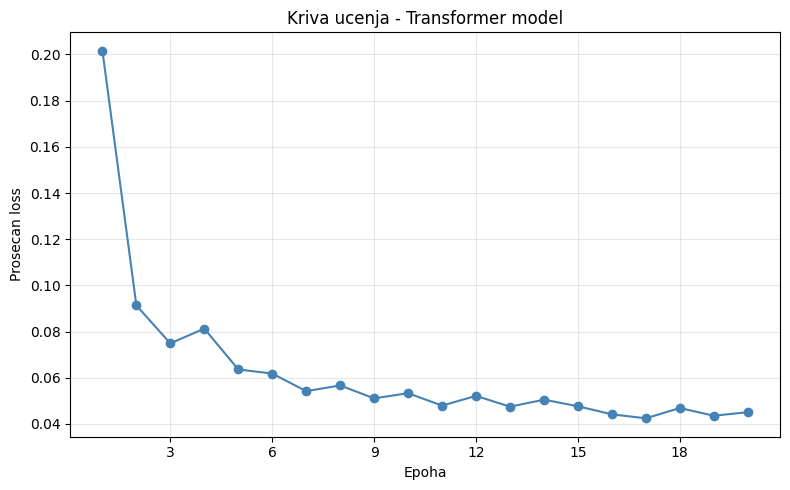

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', color='steelblue')
plt.xlabel('Epoha')
plt.ylabel('Prosecan loss')
plt.title('Kriva ucenja - Transformer model')
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "transformer_loss_curve.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

Kriva ucenja pokazuje karakteristican obrazac konvergencije transformer modela: nagli pad vrednosti funkcije greske u prvih nekoliko epoha (sa 0,20 na priblizno 0,06), nakon cega sledi sporiji pad do priblizno 0,04. Prisutne blage oscilacije izmedju uzastopnih epoha predstavljaju ocekivanu pojavu kod stohastickog optimizacionog postupka, s obzirom na to da se parametri modela azuriraju na osnovu manjih podskupova podataka (batch-eva).

### 9. Evaluacija na test skupu

Kvalitet modela ocenjuje se na test skupu, koji nije koriscen tokom treniranja. Model se prebacuje u evaluacioni rezim (eval mode), cime se iskljucuje Dropout mehanizam, a predikcije se generisu bez racunanja gradijenata, s obzirom na to da azuriranje parametara modela u ovoj fazi nije potrebno.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

y_pred_transformer = np.array(all_preds)
y_test_np = np.array(all_labels)

acc_transformer = accuracy_score(y_test_np, y_pred_transformer)
print(f"Ukupna tacnost (accuracy): {acc_transformer:.4f}")
print()

target_names = [inverse_label_mapping[i] for i in classes]
print(classification_report(y_test_np, y_pred_transformer, target_names=target_names))

Ukupna tacnost (accuracy): 0.9852

                  precision    recall  f1-score   support

          Benign       1.00      0.98      0.99     78247
   DoS GoldenEye       0.92      1.00      0.95      2057
        DoS Hulk       0.97      0.99      0.98     34569
DoS Slowhttptest       0.91      0.99      0.95      1046
   DoS slowloris       0.97      0.98      0.98      1077

        accuracy                           0.99    116996
       macro avg       0.95      0.99      0.97    116996
    weighted avg       0.99      0.99      0.99    116996



Transformer model postize ukupnu tacnost od 98,52% na testnom skupu, sto je za 1,35 procentnih poena nize u odnosu na bazni Random Forest model (99,87%). Iako je preciznost (precision) niza kod klasa DoS GoldenEye (0,92) i DoS Slowhttptest (0,91), odziv (recall) ostaje visok kod svih klasa (najmanje 0,98), sto ukazuje na to da model uspesno prepoznaje vecinu instanci svake klase, uz veci broj lazno pozitivnih predikcija kod pojedinih klasa. Dobijeni rezultati pokazuju da implementirana transformer arhitektura ostvaruje visoke performanse na posmatranom problemu viseklasne klasifikacije DoS napada.

### 10. Matrica konfuzije

Matrica konfuzije prikazuje detaljnu raspodelu predikcija transformer modela po klasama, omogucavajuci uvid u obrasce gresaka i poredjenje sa rezultatima baznog modela.

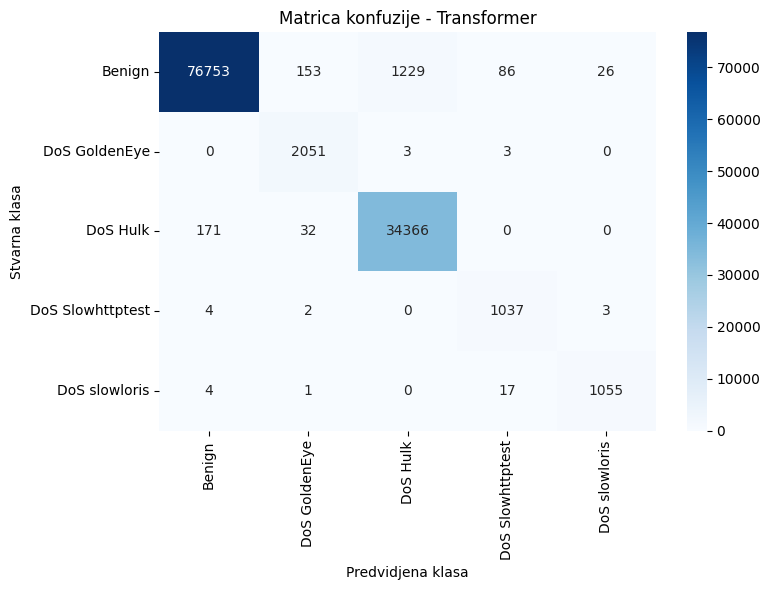

In [ ]:
from sklearn.metrics import confusion_matrix

cm_transformer = confusion_matrix(y_test_np, y_pred_transformer)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_transformer, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predvidjena klasa')
plt.ylabel('Stvarna klasa')
plt.title('Matrica konfuzije - Transformer')
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "transformer_confusion_matrix.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

Matrica konfuzije pokazuje da su najveci brojevi pogresnih klasifikacija koncentrisani izmedju klasa Benign i DoS Hulk (1.229 i 171 pogresno klasifikovanih instanci, redom), dok se kod preostalih klasa javlja manji broj gresaka, ukljucujuci i medjusobnu zamenu klasa DoS Slowhttptest i DoS slowloris. Dobijeni rezultati pruzaju detaljniji uvid u obrasce gresaka transformer modela koji nisu vidljivi iz same ukupne tacnosti.

### 11. Vizualizacija attention tezina

Radi dodatne analize ponasanja modela, izdvajaju se tezine paznje (attention weights) iz prvog sloja transformer enkodera. Posmatra se paznja koju CLS token dodeljuje svakom od 67 ulaznih atributa, usrednjena po jednom batch-u iz test skupa.

Analiza prvog sloja omogucava direktan uvid u raspodelu paznje CLS tokena prema tokenima koji predstavljaju pojedinacne ulazne atribute. Dobijene attention tezine koriste se kao dopunski uvid u ponasanje transformer modela i ne predstavljaju direktnu meru vaznosti atributa.

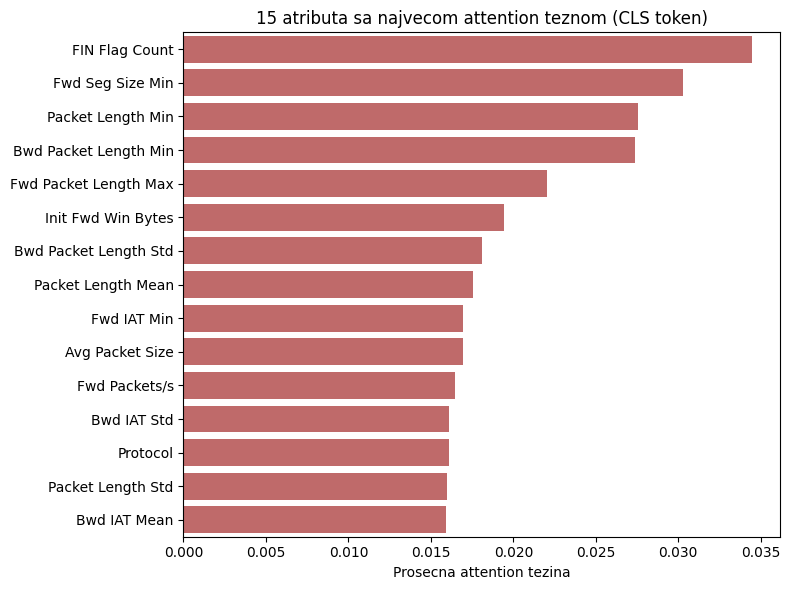

In [ ]:
import pandas as pd

model.eval()
sample_X, sample_y = next(iter(test_loader))
sample_X = sample_X.to(device)

with torch.no_grad():
    x = sample_X.unsqueeze(-1)
    tokens = x * model.feature_weights + model.feature_bias
    cls_tokens = model.cls_token.expand(sample_X.shape[0], -1, -1)
    tokens = torch.cat([cls_tokens, tokens], dim=1)

    _, attn_weights = model.transformer.layers[0].self_attn(
        tokens, tokens, tokens, need_weights=True, average_attn_weights=True
    )

cls_attention = attn_weights[:, 0, 1:]
avg_attention = cls_attention.mean(dim=0).cpu().numpy()

attention_df = pd.DataFrame({
    'Atribut': feature_cols,
    'Paznja': avg_attention
}).sort_values('Paznja', ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=attention_df, x='Paznja', y='Atribut', color='indianred')
plt.title('15 atributa sa najvecom attention teznom (CLS token)')
plt.xlabel('Prosecna attention tezina')
plt.ylabel('')
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "transformer_attention_weights.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

Na analiziranom batch-u iz test skupa, attention tezine prvog transformer sloja pokazuju relativno ravnomernu raspodelu paznje CLS tokena preko posmatranih atributa, sa blagim naglaskom na atribute vezane za velicinu paketa i mrezne zastavice (FIN Flag Count, Fwd Seg Size Min).

### 12. Vizualizacija prostora reprezentacija (t-SNE)

Radi vizuelnog uvida u to kako model organizuje razlicite tipove saobracaja u naucenom prostoru reprezentacija, primenjuje se t-SNE tehnika redukcije dimenzionalnosti nad CLS embeddinzima uzorka test skupa, cime se 32-dimenzionalni vektori projektuju u dvodimenzionalni prostor pogodan za vizuelizaciju.

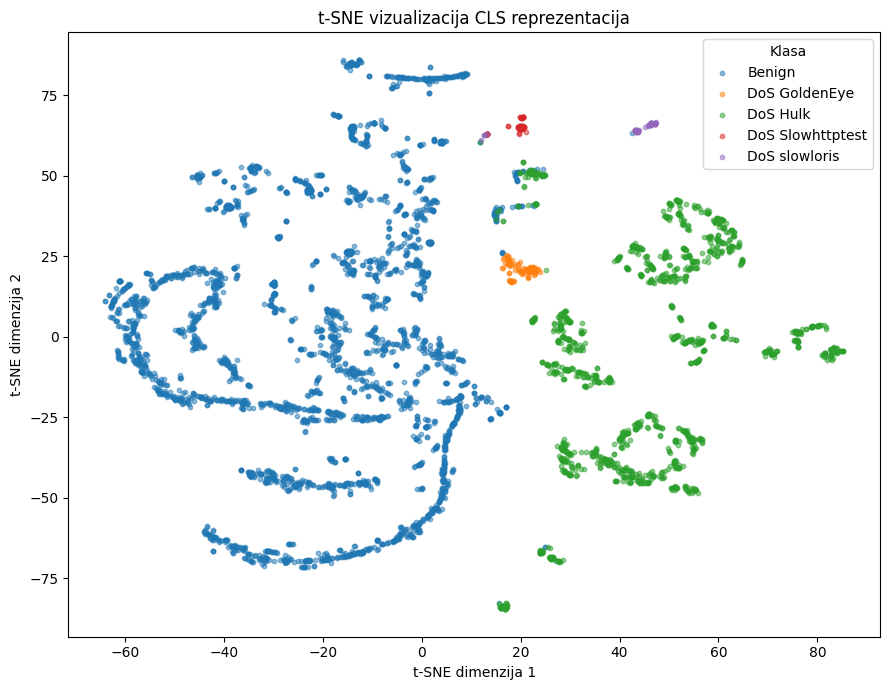

In [ ]:
from sklearn.manifold import TSNE

model.eval()

sample_size = 5000

rng = np.random.default_rng(42)
indices = rng.choice(len(X_test), sample_size, replace=False)
X_sample = torch.tensor(X_test[indices], dtype=torch.float32).to(device)
y_sample = y_test[indices]

with torch.no_grad():
    x = X_sample.unsqueeze(-1)
    tokens = x * model.feature_weights + model.feature_bias
    cls_tokens = model.cls_token.expand(X_sample.shape[0], -1, -1)
    tokens = torch.cat([cls_tokens, tokens], dim=1)
    encoded = model.transformer(tokens)
    cls_embeddings = encoded[:, 0, :].cpu().numpy()

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(cls_embeddings)

plt.figure(figsize=(9, 7))
for cls_name, cls_idx in sorted(label_mapping.items(), key=lambda x: x[1]):
    mask = y_sample == cls_idx
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=cls_name,
        alpha=0.5,
        s=10
    )

plt.legend(title='Klasa')
plt.title('t-SNE vizualizacija CLS reprezentacija')
plt.xlabel('t-SNE dimenzija 1')
plt.ylabel('t-SNE dimenzija 2')
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "transformer_tsne.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

t-SNE vizualizacija pokazuje izrazeno grupisanje CLS reprezentacija razlicitih tipova DoS napada (DoS Hulk, DoS GoldenEye, DoS Slowhttptest i DoS slowloris) u projektovanom dvodimenzionalnom prostoru. Reprezentacije benignog saobracaja zauzimaju siri i heterogeniji prostor u odnosu na posmatrane DoS klase.

U okviru prikazane t-SNE projekcije uocava se jasno razdvajanje vecine reprezentacija razlicitih klasa, sto pruza vizuelni uvid u strukturu reprezentacija naucenih transformer modelom.

### 13. Provera stabilnosti rezultata (visestruko treniranje)

Radi provere stabilnosti i pouzdanosti dobijenih rezultata, model se trenira tri puta sa razlicitim vrednostima semena nasumicnosti (random seed), nakon cega se izracunava prosecna tacnost i standardna devijacija na testnom skupu.

In [ ]:
def train_and_evaluate(seed):
    torch.manual_seed(seed)

    m = TransformerClassifier(
        num_features=X_train.shape[1],
        num_classes=len(label_mapping),
        d_model=32, num_heads=4, num_layers=2, dropout=0.1
    ).to(device)

    opt = torch.optim.Adam(m.parameters(), lr=0.001)

    m.train()
    for epoch in range(num_epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            opt.zero_grad()
            logits = m(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            opt.step()

    m.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            logits = m(X_batch)
            p = torch.argmax(logits, dim=1)
            preds.extend(p.cpu().numpy())
            labels.extend(y_batch.numpy())

    return accuracy_score(labels, preds)

In [ ]:
seeds = [42, 123, 7]
accuracies = []

for s in seeds:
    acc_s = train_and_evaluate(s)
    accuracies.append(acc_s)
    print(f"Seed {s}: tacnost = {acc_s:.4f}")

mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)

print(f"\nProsecna tacnost: {mean_acc:.4f} ± {std_acc:.4f}")

Seed 42: tacnost = 0.9852
Seed 123: tacnost = 0.9857
Seed 7: tacnost = 0.9849

Prosecna tacnost: 0.9853 ± 0.0004


Rezultati dobijeni za tri razlicite vrednosti seed-a pokazuju malu varijabilnost performansi modela izmedju pojedinacnih treniranja. Prosecna tacnost iznosi 98,53%, uz standardnu devijaciju od 0,04 procentna poena.

Dobijeni rezultati ukazuju na to da je, u okviru sprovedena tri treniranja, model ostvarivao stabilne performanse uprkos promeni inicijalnog slucajnog stanja.

### 14. Cuvanje rezultata transformer modela

Rezultati transformer modela, ukljucujuci ukupnu tacnost, predikcije i stvarne labele testnog skupa, cuvaju se u `data` direktorijumu projekta radi kasnijeg formalnog poredjenja sa baznim modelom.

In [ ]:
transformer_results = {
    'accuracy': acc_transformer,
    'y_pred': y_pred_transformer,
    'y_test': y_test_np
}

joblib.dump(
    transformer_results,
    DATA_DIR / "transformer_results.pkl"
)

print("Rezultati transformer modela sacuvani.")

Rezultati transformer modela sacuvani.


**Sledeci korak:** Beleznica `05_model_comparison.ipynb`, u okviru koje se rezultati Random Forest i transformer modela formalno porede primenom McNemar testa.